In [ ]:
!pip install datasets[audio] soundfile librosa torchcodec

In [ ]:
from datasets import load_dataset
from datasets import Audio

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
minds = minds.cast_column("audio", Audio(sampling_rate=16000))

In [ ]:
from transformers import pipeline

# automaes the entire flow of training
classifier = pipeline(
    "audio-classification",
    model="anton-l/xtreme_s_xlsr_300m_minds14",
)

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

In [ ]:
example = minds[0]

In [ ]:
classifier(example["audio"]["array"])

[{'score': 0.9623644948005676, 'label': 'pay_bill'},
 {'score': 0.02867867611348629, 'label': 'freeze'},
 {'score': 0.0034296379890292883, 'label': 'card_issues'},
 {'score': 0.0020605006720870733, 'label': 'abroad'},
 {'score': 0.0008625715272501111, 'label': 'high_value_payment'},
 {'score': 0.0007367239450104535, 'label': 'direct_debit'},
 {'score': 0.00040874729165807366, 'label': 'latest_transactions'},
 {'score': 0.00034171840525232255, 'label': 'joint_account'},
 {'score': 0.00033396665821783245, 'label': 'address'},
 {'score': 0.0003278649819549173, 'label': 'balance'},
 {'score': 0.00015173130668699741, 'label': 'app_error'},
 {'score': 0.00014879457012284547, 'label': 'atm_limit'},
 {'score': 8.886776777217165e-05, 'label': 'cash_deposit'},
 {'score': 6.577015301445499e-05, 'label': 'business_loan'}]

In [ ]:
id2label = minds.features["intent_class"].int2str

id2label(example["intent_class"])

# literally just get the right model throw it into pipeline call it direclty on twhatever you're working on



'pay_bill'

In [ ]:
!pip install --upgrade transformers

In [ ]:
from transformers import pipeline

pipe = pipeline("text-to-speech", model="suno/bark-small")

text = "Lebron james sat on a tree and twiddled his thumbs. Harry you're the best he said."

output = pipe(text)

Loading weights:   0%|          | 0/542 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'min_eos_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/t

In [ ]:
output

{'audio': array([ 0.04354998,  0.04502749,  0.04943192, ...,  0.00580478,
         0.00069911, -0.01094796], dtype=float32),
 'sampling_rate': 24000}

In [ ]:
output['audio'].shape

(291840,)

In [ ]:
from IPython.display import Audio

Audio(output["audio"], rate=output["sampling_rate"])

In [ ]:
fr_text = "Contrairement à une idée répandue, le nombre de points sur les élytres d'une coccinelle ne correspond pas à son âge, ni en nombre d'années, ni en nombre de mois. "
output = pipe(fr_text)

Audio(output["audio"], rate=output["sampling_rate"])

[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/doc

In [ ]:
song = """♪ White Iverson, when I started ballin', I was young
You gon' think about me when I'm gone
I need that money like the ring I never won, I won ♪ """

output = pipe(song)

Audio(output["audio"], rate=output["sampling_rate"])

[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/doc

In [ ]:
music_pipe = pipeline("text-to-audio", model="facebook/musicgen-small")

text = "Drake song collab with Future. Hype with a trap feel to it."
forward_params = {"max_new_tokens": 512}

output = music_pipe(text, forward_params=forward_params)


[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

In [ ]:
output

{'audio': array([-0.16126725, -0.16103588, -0.16018012, ..., -0.1725256 ,
        -0.17677441, -0.18362626], dtype=float32),
 'sampling_rate': 32000}

In [ ]:
output["audio"].shape

(325760,)

In [ ]:
Audio(output["audio"], rate = output["sampling_rate"])

In [ ]:
ds = load_dataset("facebook/voxpopuli", "en", split="train", streaming=True)


Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
first_three = ds.take(3)

In [ ]:
third = next(item for i, item in enumerate(first_three) if i == 2)

In [ ]:
third

{'audio_id': '20180314-0900-PLENARY-13-en_20180314-16:03:18_3',
 'language': 0,
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7b4e86815480>,
 'raw_text': 'In order to increase the preparedness at national and EU level, the key word to overcome those challenges is cooperation and the multidimensional aspects public private cooperation, cooperation between Member States, economic cross border and cross sector collaboration,',
 'normalized_text': 'in order to increase the preparedness at national and eu level the key word to overcome those challenges is cooperation and the multidimensional aspects public private cooperation cooperation between member states economic cross border and cross sector collaboration',
 'gender': 'female',
 'speaker_id': 'None',
 'is_gold_transcript': True,
 'accent': 'None'}

In [ ]:
input = third['audio']
samples = input.get_all_samples()

In [ ]:
samples

AudioSamples:
  data (shape): torch.Size([1, 317418])
  pts_seconds: 0.0
  duration_seconds: 19.838625
  sample_rate: 16000

In [ ]:
import numpy as np

y_dft = np.fft.rfft(samples.data[0])

In [ ]:
samples.data[0].numpy().shape


(317418,)

Plotting the waveform and spectogram

[Text(0.5, 1.0, 'Frequency domain'),
 Text(0.5, 23.52222222222222, 'Frequency (Hz)'),
 Text(42.722222222222214, 0.5, 'Magnitue')]

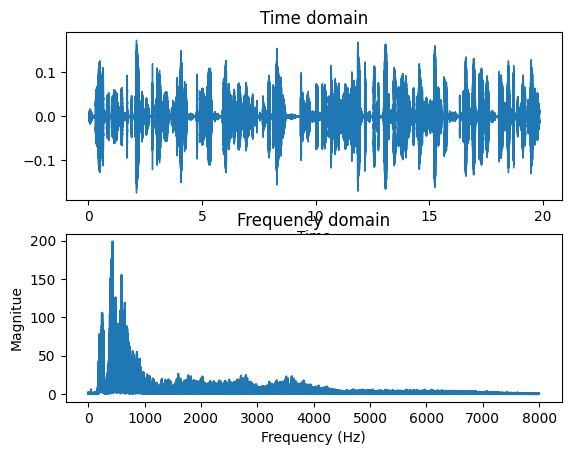

In [ ]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

frequencies = np.fft.rfftfreq(len(samples.data[0]), d = 1/samples.sample_rate)


fig, ax = plt.subplots(2)
ax[0].set(title="Time domain")
librosa.display.waveshow(samples.data[0].numpy(), sr=samples.sample_rate, ax=ax[0])


ax[1].plot(frequencies, np.abs(y_dft))
ax[1].set(title="Frequency domain", xlabel="Frequency (Hz)",
          ylabel="Magnitue")


In [ ]:
from transformers import pipeline

pipe = pipeline("automatic-speech-recognition", model="openai/whisper-small")

out = pipe(samples.data)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

In [ ]:
out

{'text': ' In order to increase the preparedness at national and EU level, the key word to overcome those challenges is cooperation. And the multi-dimensional aspects, public-private cooperation, cooperation between member states, economic cross-border and cross-sector collaboration,'}

In [ ]:
third['raw_text']

'In order to increase the preparedness at national and EU level, the key word to overcome those challenges is cooperation and the multidimensional aspects public private cooperation, cooperation between Member States, economic cross border and cross sector collaboration,'